## Analisis Exploratorio de Datos (EDA)

### Por: Grupo 12 - ITBA
### Fecha: 2026-03-18

### Descripcion:
Exploracion de la base limpia de ventas para entender distribuciones, patrones temporales, concentracion geografica, productos clave y comportamiento de cancelaciones.

## Importar librerias

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## Cargar datos limpios

In [2]:
df = pd.read_parquet("../../data/03_primary/ventas_limpias.parquet")
df_cancel = pd.read_parquet("../../data/03_primary/cancelaciones.parquet")

print(f"Ventas: {len(df):,} registros | {df['CustomerID'].nunique():,} clientes")
print(f"Cancelaciones: {len(df_cancel):,} registros")

Ventas: 397,884 registros | 4,338 clientes
Cancelaciones: 8,905 registros


## 1. Distribucion de Revenue

Estadisticas de Revenue por transaccion:
count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000

Revenue total: $8,911,407.90


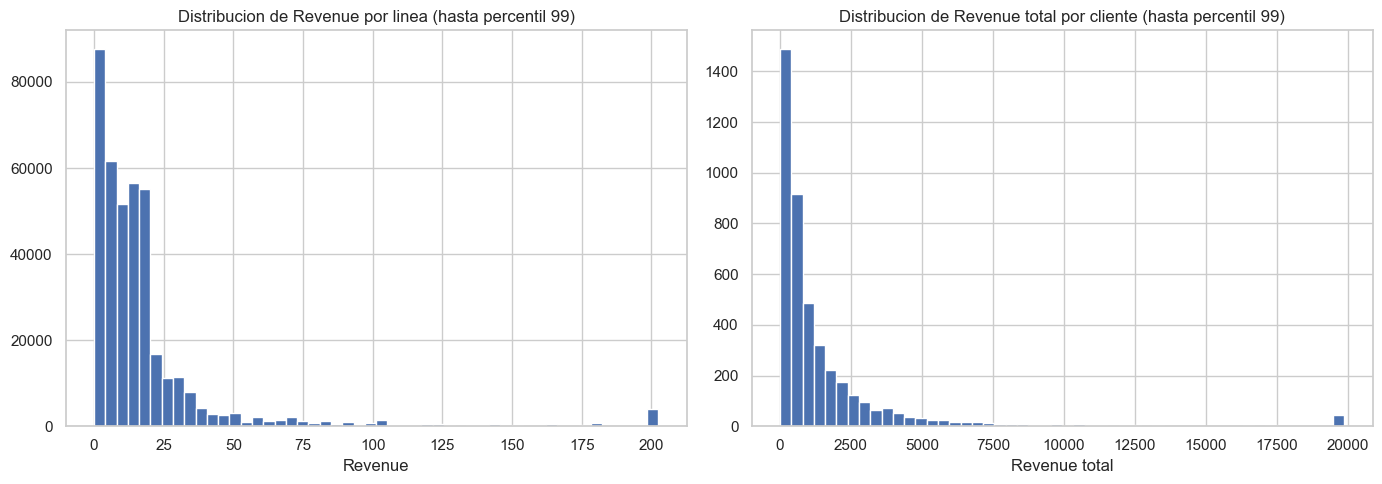

In [3]:
print("Estadisticas de Revenue por transaccion:")
print(df["Revenue"].describe().to_string())
print(f"\nRevenue total: ${df['Revenue'].sum():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Revenue"].clip(upper=df["Revenue"].quantile(0.99)).hist(bins=50, ax=axes[0], edgecolor="white")
axes[0].set_title("Distribucion de Revenue por linea (hasta percentil 99)")
axes[0].set_xlabel("Revenue")

revenue_cliente = df.groupby("CustomerID")["Revenue"].sum()
revenue_cliente.clip(upper=revenue_cliente.quantile(0.99)).hist(
    bins=50, ax=axes[1], edgecolor="white"
)
axes[1].set_title("Distribucion de Revenue total por cliente (hasta percentil 99)")
axes[1].set_xlabel("Revenue total")

plt.tight_layout()
plt.savefig("../../data/08_reporting/dist_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Ventas por pais

Top 10 paises por revenue:
                    Revenue  Porcentaje
Country                                
United Kingdom  7308391.554       82.01
Netherlands      285446.340        3.20
EIRE             265545.900        2.98
Germany          228867.140        2.57
France           209024.050        2.35
Australia        138521.310        1.55
Spain             61577.110        0.69
Switzerland       56443.950        0.63
Belgium           41196.340        0.46
Sweden            38378.330        0.43


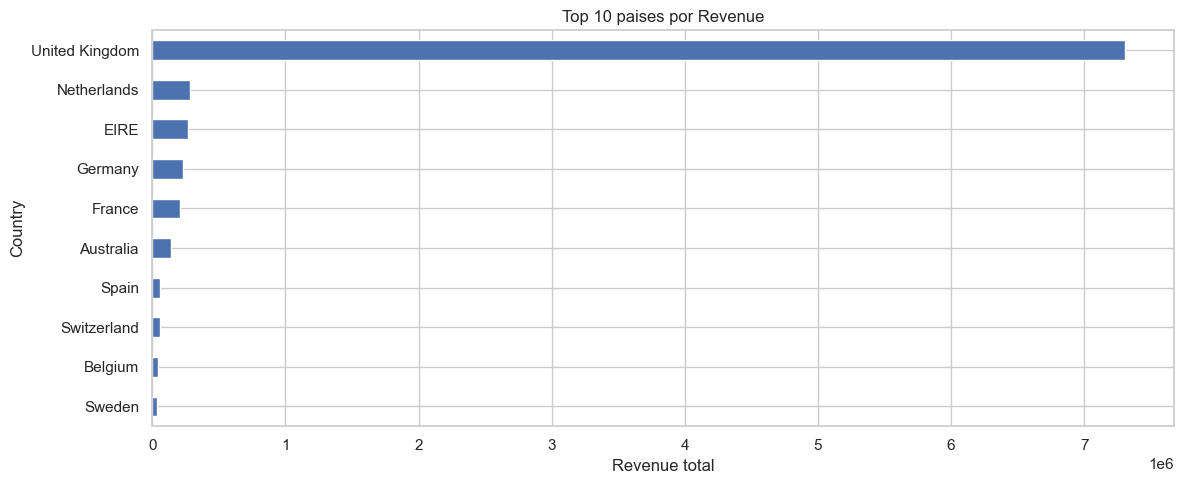

In [4]:
rev_pais = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
rev_pais_pct = (rev_pais / rev_pais.sum() * 100).round(2)

top_paises = pd.DataFrame({"Revenue": rev_pais.head(10), "Porcentaje": rev_pais_pct.head(10)})
print("Top 10 paises por revenue:")
print(top_paises.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
rev_pais.head(10).plot(kind="barh", ax=ax)
ax.set_title("Top 10 paises por Revenue")
ax.set_xlabel("Revenue total")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../../data/08_reporting/revenue_por_pais.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Evolucion temporal de ventas

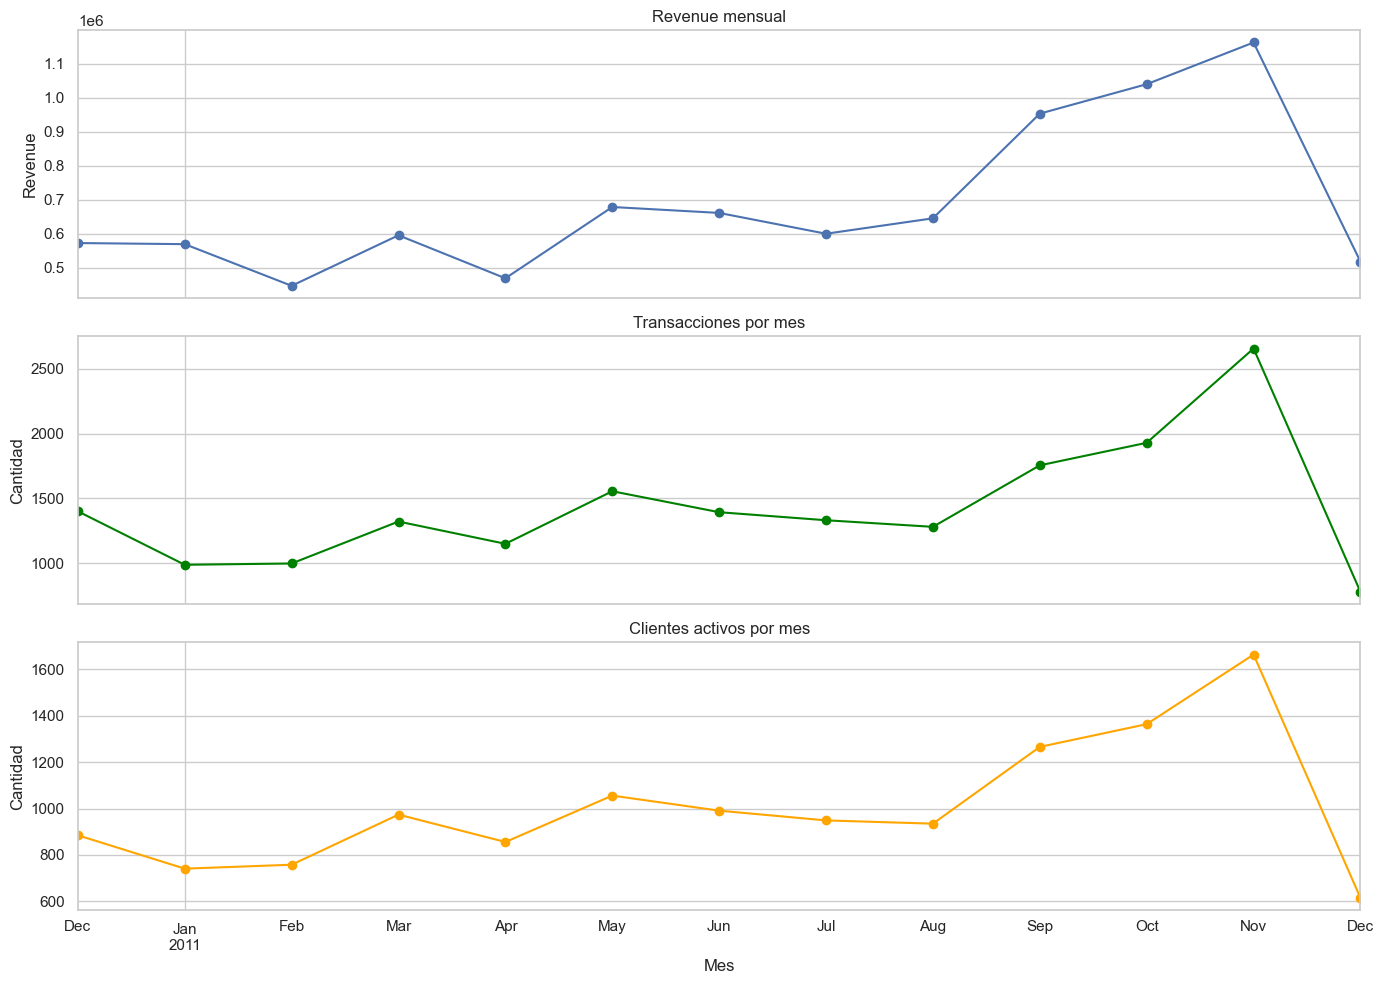

In [5]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

ventas_mes = df.groupby("YearMonth").agg(
    revenue=("Revenue", "sum"),
    transacciones=("InvoiceNo", "nunique"),
    clientes=("CustomerID", "nunique"),
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ventas_mes["revenue"].plot(ax=axes[0], marker="o")
axes[0].set_title("Revenue mensual")
axes[0].set_ylabel("Revenue")

ventas_mes["transacciones"].plot(ax=axes[1], marker="o", color="green")
axes[1].set_title("Transacciones por mes")
axes[1].set_ylabel("Cantidad")

ventas_mes["clientes"].plot(ax=axes[2], marker="o", color="orange")
axes[2].set_title("Clientes activos por mes")
axes[2].set_ylabel("Cantidad")
axes[2].set_xlabel("Mes")

plt.tight_layout()
plt.savefig("../../data/08_reporting/evolucion_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Patrones por dia de semana y hora

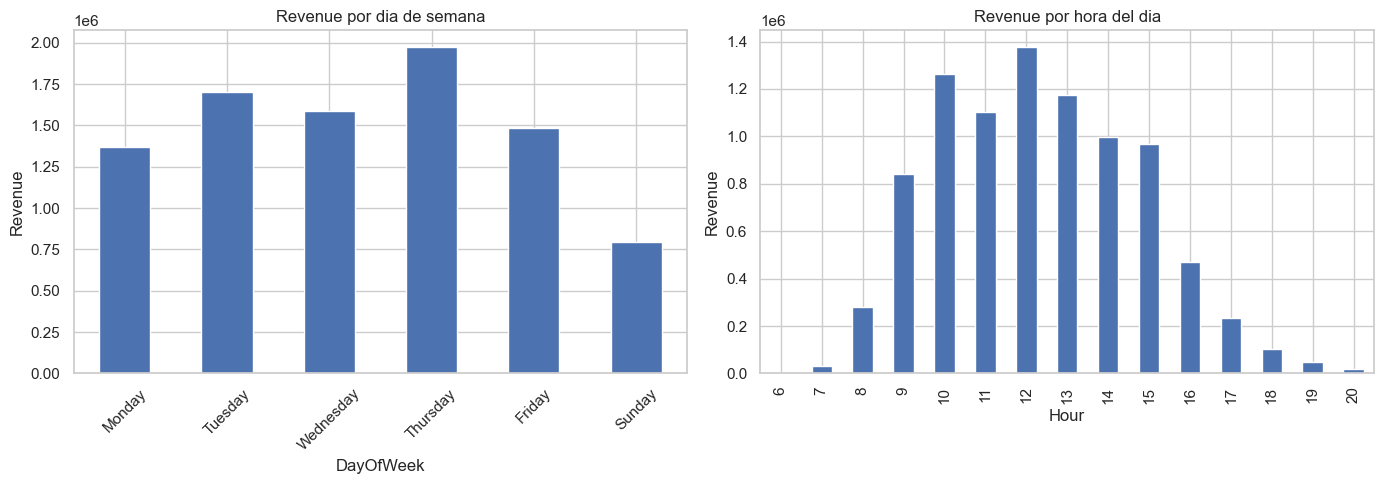

In [6]:
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

dias_orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rev_dia = df.groupby("DayOfWeek")["Revenue"].sum().reindex(dias_orden)
rev_dia.plot(kind="bar", ax=axes[0], edgecolor="white")
axes[0].set_title("Revenue por dia de semana")
axes[0].set_ylabel("Revenue")
axes[0].tick_params(axis="x", rotation=45)

rev_hora = df.groupby("Hour")["Revenue"].sum()
rev_hora.plot(kind="bar", ax=axes[1], edgecolor="white")
axes[1].set_title("Revenue por hora del dia")
axes[1].set_ylabel("Revenue")

plt.tight_layout()
plt.savefig("../../data/08_reporting/patrones_temporales.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Top productos

In [7]:
top_prods = (
    df.groupby(["StockCode", "Description"])
    .agg(
        revenue=("Revenue", "sum"),
        cantidad=("Quantity", "sum"),
        transacciones=("InvoiceNo", "nunique"),
    )
    .sort_values("revenue", ascending=False)
    .head(15)
)

print("Top 15 productos por revenue:")
top_prods

Top 15 productos por revenue:


,,revenue,cantidad,transacciones
StockCode,Description,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
22423,REGENCY CAKESTAND 3 TIER,142592.95,12402,1703
85123A,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,36725,1971
85099B,JUMBO BAG RED RETROSPOT,85220.78,46181,1600
23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195
POST,POSTAGE,77803.96,3120,1099
47566,PARTY BUNTING,68844.33,15291,1379
84879,ASSORTED COLOUR BIRD ORNAMENT,56580.34,35362,1375
M,Manual,53779.93,7173,253


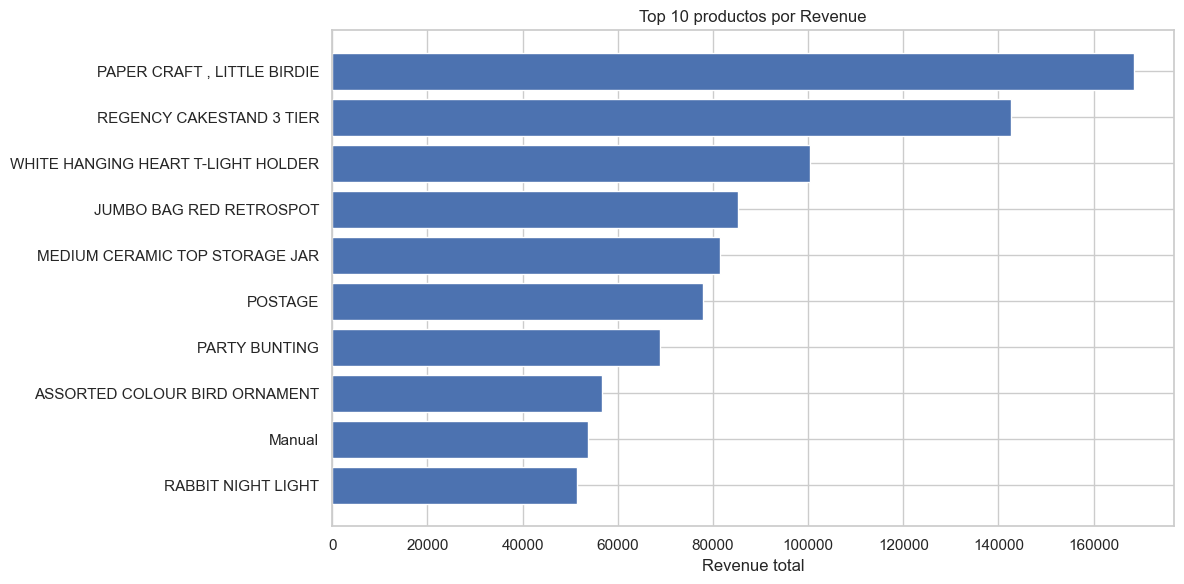

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
top_10 = top_prods.head(10).reset_index()
ax.barh(top_10["Description"].str[:40], top_10["revenue"])
ax.set_title("Top 10 productos por Revenue")
ax.set_xlabel("Revenue total")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../../data/08_reporting/top_productos.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Concentracion de clientes (Pareto)

El top 20% de clientes genera el 74.6% del revenue


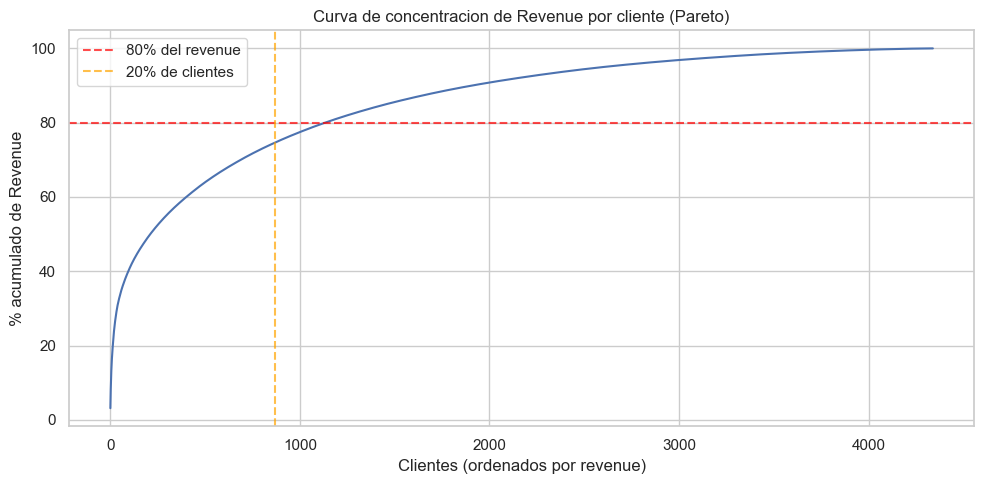

In [9]:
rev_cliente = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
rev_acum = rev_cliente.cumsum() / rev_cliente.sum() * 100

top_20_pct = rev_acum.iloc[int(len(rev_acum) * 0.2)]
print(f"El top 20% de clientes genera el {top_20_pct:.1f}% del revenue")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(rev_acum) + 1), rev_acum.values)
ax.axhline(y=80, color="red", linestyle="--", alpha=0.7, label="80% del revenue")
ax.axvline(
    x=len(rev_acum) * 0.2, color="orange", linestyle="--", alpha=0.7, label="20% de clientes"
)
ax.set_title("Curva de concentracion de Revenue por cliente (Pareto)")
ax.set_xlabel("Clientes (ordenados por revenue)")
ax.set_ylabel("% acumulado de Revenue")
ax.legend()
plt.tight_layout()
plt.savefig("../../data/08_reporting/pareto_clientes.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Analisis de cancelaciones

In [10]:
print(f"Total cancelaciones: {len(df_cancel):,}")
print(f"Clientes con cancelaciones: {df_cancel['CustomerID'].nunique():,}")
print(
    f"Valor absoluto cancelado: ${df_cancel['Quantity'].abs().mul(df_cancel['UnitPrice']).sum():,.2f}"
)

cancel_por_cliente = df_cancel.groupby("CustomerID").size().sort_values(ascending=False)
print("\nTop 10 clientes con mas cancelaciones:")
print(cancel_por_cliente.head(10).to_string())

Total cancelaciones: 8,905
Clientes con cancelaciones: 1,589
Valor absoluto cancelado: $611,342.09

Top 10 clientes con mas cancelaciones:
CustomerID
14911    226
17841    136
17511    113
15311    112
12607    101
14410     93
13798     90
14606     82
13113     79
12471     71


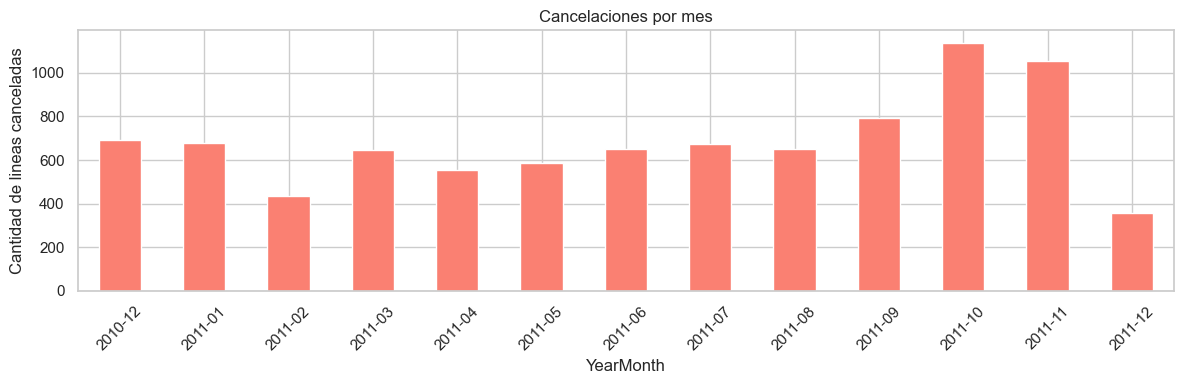

In [11]:
df_cancel["YearMonth"] = df_cancel["InvoiceDate"].dt.to_period("M")
cancel_mes = df_cancel.groupby("YearMonth").size()

fig, ax = plt.subplots(figsize=(12, 4))
cancel_mes.plot(kind="bar", ax=ax, edgecolor="white", color="salmon")
ax.set_title("Cancelaciones por mes")
ax.set_ylabel("Cantidad de lineas canceladas")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../../data/08_reporting/cancelaciones_por_mes.png", dpi=150, bbox_inches="tight")
plt.show()

## Resultados y conclusiones

**Concentracion geografica:** United Kingdom domina ampliamente las ventas (~82% del revenue). Los mercados secundarios son Alemania, Francia e Irlanda.

**Temporalidad:** Se observa un pico de ventas hacia fin de anio (septiembre-noviembre), probablemente por compras navidenas. No hay ventas los sabados.

**Concentracion de clientes:** Se confirma un patron Pareto marcado: un porcentaje reducido de clientes genera la mayor parte del revenue. Esto justifica la segmentacion.

**Productos:** Unos pocos productos explican una parte significativa de la facturacion.

**Cancelaciones:** Representan una proporcion menor pero no despreciable. Algunos clientes concentran muchas cancelaciones, lo que puede ser una senal de alerta.

### Proximos pasos
- Construir tabla RFM por cliente para segmentacion
- Aplicar clustering para identificar segmentos